# **DSAI 4103 Business Analytics - Course Project**


**Student Name:** Lena Abu Swaileh

**Student ID:** 60302049

### **Business Problem and Objectives**

In digital commerce, companies invest in campaigns and customer engagement activities to increase conversions, but not every customer interaction leads to a purchase. This project focuses on understanding customer behavior and predicting whether an event is likely to result in a purchase.

**The objectives of this project are to:**

- Analyze customer, product, campaign, transaction, and event data
- Identify the factors associated with purchase behavior
- Build and compare predictive models for purchase prediction
- Explain model predictions using SHAP
- Evaluate fairness through bias analysis
- Prepare the final output for dashboard reporting in Power BI or Tableau

### **Dataset Overview**

This project uses a multi-file marketing and e-commerce dataset consisting of 5 related CSV files. Together, these files provide information about customer profiles, products, campaigns, transactions, and user events.

- **customers.csv** contains customer-level information such as signup date, country, age, gender, loyalty tier, and acquisition channel.

- **products.csv** includes product-related information such as category, brand, base price, launch date, and premium status.

- **campaigns.csv** includes information about marketing campaigns, including channel, objective, campaign dates, target segment, and expected uplift.

- **transactions.csv** records completed purchases and includes timestamp, customer ID, product ID, quantity, discount, gross revenue, campaign ID, and refund information.

- **events.csv** contains detailed customer interaction data, including timestamp, session ID, event type, device type, traffic source, page category, session duration, and experiment group. This file captures online behavior such as views, clicks, add-to-cart actions, purchases, and bounces.

These files are linked through shared identifiers such as customer_id, product_id, and campaign_id, which makes it possible to combine them into one dataset for analysis and modeling.

### **Data Source and Size**

**Dataset Link:** https://www.kaggle.com/datasets/geethasagarbonthu/marketing-and-e-commerce-analytics-dataset?resource=download


The dataset used in this project consists of five CSV files obtained for marketing and e-commerce analysis. It follows a relational-style structure in which each file represents a different part of the business process.

The dataset includes 100000 customer records in customers.csv, 2000 product records in products.csv, 50 campaign records in campaigns.csv, 103127 transaction records in transactions.csv, and 2000000 event records in events.csv. This provides enough volume and variety to support meaningful analysis and predictive modeling.

The dataset includes shared identifiers which allow the files to be merged for integrated analysis. Because the dataset contains both demographic and behavioral variables, it makes it suitable for studying purchase behavior.

### **Dataset Suitability and Target Variable**

The dataset is suitable because it covers customer information, campaign exposure, product details, online behavior, and purchase activity across multiple related files. This makes it appropriate for analyzing conversion behavior and building a prediction model.

The prediction goal is to estimate whether an event will result in a purchase. Purchase events are treated as positive cases, while all other events are treated as non-purchase cases, creating a binary classification problem.

## **1. Import Libraries**

In [1]:
!pip install "flaml[automl]" -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from flaml import AutoML
import shap
import joblib

## **2. Load the Datasets**



In [3]:
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
campaigns = pd.read_csv("campaigns.csv")
transactions = pd.read_csv("transactions.csv")
events = pd.read_csv("events.csv")

In [4]:
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Campaigns shape:", campaigns.shape)
print("Transactions shape:", transactions.shape)
print("Events shape:", events.shape)

Customers shape: (100000, 7)
Products shape: (2000, 6)
Campaigns shape: (50, 7)
Transactions shape: (103127, 9)
Events shape: (2000000, 12)


## **3. Inspect the Data**

The datasets were inspected by reviewing their first rows, column names, data types, missing values, and some visuals.

**a. Preview the first rows**

In [5]:
customers.head()

,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,1,2021-04-08,BR,48,Male,Bronze,Referral
1,2,2023-04-28,IN,36,Female,Silver,Organic
2,3,2022-12-18,UK,35,Female,Silver,Organic
3,4,2022-04-26,US,45,Male,Silver,Paid Search
4,5,2022-04-20,IN,53,Male,Silver,Organic


In [6]:
products.head()


,product_id,category,brand,base_price,launch_date,is_premium
0,1,Grocery,Brand_58,14.19,2021-08-02,0
1,2,Fashion,Brand_1,25.80,2021-09-14,0
2,3,Electronics,Brand_70,165.46,2021-01-18,1
3,4,Fashion,Brand_56,75.45,2023-03-03,1
4,5,Sports,Brand_1,72.50,2022-04-19,1


In [7]:
campaigns.head()


,campaign_id,channel,objective,start_date,end_date,target_segment,expected_uplift
0,1,Paid Search,Cross-sell,2021-10-25,2021-11-26,Deal Seekers,0.022
1,2,Email,Retention,2021-10-24,2021-12-24,Deal Seekers,0.116
2,3,Email,Reactivation,2023-10-08,2023-11-30,Churn Risk,0.100
3,4,Display,Reactivation,2022-07-25,2022-10-07,Deal Seekers,0.111
4,5,Social,Acquisition,2022-07-09,2022-09-29,New Customers,0.144


In [8]:
transactions.head()


,transaction_id,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
0,1,2021-12-27 08:25:15,59540,1630.0,3,0.00,43.74,0,0
1,2,2023-06-06 21:14:26,54871,1901.0,3,0.00,174.78,21,0
2,3,2023-08-31 05:29:54,51818,1884.0,1,0.00,40.61,37,0
3,4,2022-06-26 20:33:46,18164,1114.0,2,0.15,68.76,13,0
4,5,2023-07-26 18:12:35,86915,408.0,1,0.00,14.64,4,0


In [9]:
events.head()

,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group
0,1,2021-01-14 13:35:43,43812,535101,view,1004.0,desktop,Email,43,PLP,115.1,Control
1,2,2021-12-03 21:36:50,71340,96426,add_to_cart,986.0,desktop,Email,10,PDP,32.4,Variant_A
2,3,2021-12-27 08:25:15,59540,220126,purchase,1630.0,mobile,Organic,0,PDP,190.7,Variant_A
3,4,2022-01-22 15:06:54,3601,484555,add_to_cart,1532.0,desktop,Paid Search,30,Checkout,134.8,Variant_B
4,5,2021-05-10 12:03:09,92735,60646,bounce,NaN,desktop,Email,26,PLP,53.1,Variant_A


**b. Check column names**

In [10]:
print("Customers columns:", customers.columns)
print("\nProducts columns:", products.columns)
print("\nCampaigns columns:", campaigns.columns)
print("\nTransactions columns:", transactions.columns)
print("\nEvents columns:", events.columns)

Customers columns: Index(['customer_id', 'signup_date', 'country', 'age', 'gender',
       'loyalty_tier', 'acquisition_channel'],
      dtype='object')

Products columns: Index(['product_id', 'category', 'brand', 'base_price', 'launch_date',
       'is_premium'],
      dtype='object')

Campaigns columns: Index(['campaign_id', 'channel', 'objective', 'start_date', 'end_date',
       'target_segment', 'expected_uplift'],
      dtype='object')

Transactions columns: Index(['transaction_id', 'timestamp', 'customer_id', 'product_id', 'quantity',
       'discount_applied', 'gross_revenue', 'campaign_id', 'refund_flag'],
      dtype='object')

Events columns: Index(['event_id', 'timestamp', 'customer_id', 'session_id', 'event_type',
       'product_id', 'device_type', 'traffic_source', 'campaign_id',
       'page_category', 'session_duration_sec', 'experiment_group'],
      dtype='object')


**c. Check data types**

In [11]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          100000 non-null  int64 
 1   signup_date          100000 non-null  object
 2   country              100000 non-null  object
 3   age                  100000 non-null  int64 
 4   gender               100000 non-null  object
 5   loyalty_tier         100000 non-null  object
 6   acquisition_channel  100000 non-null  object
dtypes: int64(2), object(5)
memory usage: 5.3+ MB


In [12]:
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   product_id   2000 non-null   int64  
 1   category     2000 non-null   object 
 2   brand        2000 non-null   object 
 3   base_price   2000 non-null   float64
 4   launch_date  2000 non-null   object 
 5   is_premium   2000 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 93.9+ KB


In [13]:
campaigns.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   campaign_id      50 non-null     int64  
 1   channel          50 non-null     object 
 2   objective        50 non-null     object 
 3   start_date       50 non-null     object 
 4   end_date         50 non-null     object 
 5   target_segment   50 non-null     object 
 6   expected_uplift  50 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ KB


In [14]:
transactions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103127 entries, 0 to 103126
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    103127 non-null  int64  
 1   timestamp         103127 non-null  object 
 2   customer_id       103127 non-null  int64  
 3   product_id        92678 non-null   float64
 4   quantity          103127 non-null  int64  
 5   discount_applied  103127 non-null  float64
 6   gross_revenue     92678 non-null   float64
 7   campaign_id       103127 non-null  int64  
 8   refund_flag       103127 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 7.1+ MB


In [15]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   event_id              int64  
 1   timestamp             object 
 2   customer_id           int64  
 3   session_id            int64  
 4   event_type            object 
 5   product_id            float64
 6   device_type           object 
 7   traffic_source        object 
 8   campaign_id           int64  
 9   page_category         object 
 10  session_duration_sec  float64
 11  experiment_group      object 
dtypes: float64(2), int64(4), object(6)
memory usage: 183.1+ MB


**d. Count missing values**

In [16]:
print("Customers missing values:")
print(customers.isnull().sum())

print("\nProducts missing values:")
print(products.isnull().sum())

print("\nCampaigns missing values:")
print(campaigns.isnull().sum())

print("\nTransactions missing values:")
print(transactions.isnull().sum())

print("\nEvents missing values:")
print(events.isnull().sum())

Customers missing values:
customer_id            0
signup_date            0
country                0
age                    0
gender                 0
loyalty_tier           0
acquisition_channel    0
dtype: int64

Products missing values:
product_id     0
category       0
brand          0
base_price     0
launch_date    0
is_premium     0
dtype: int64

Campaigns missing values:
campaign_id        0
channel            0
objective          0
start_date         0
end_date           0
target_segment     0
expected_uplift    0
dtype: int64

Transactions missing values:
transaction_id          0
timestamp               0
customer_id             0
product_id          10449
quantity                0
discount_applied        0
gross_revenue       10449
campaign_id             0
refund_flag             0
dtype: int64

Events missing values:
event_id                     0
timestamp                    0
customer_id                  0
session_id                   0
event_type                   0
pr

**e. Inspection visuals**

In [17]:
pastel_palette = ['#f4a6c1', '#cdb4db', '#bde0fe', '#ffc8dd', '#e0bbe4']

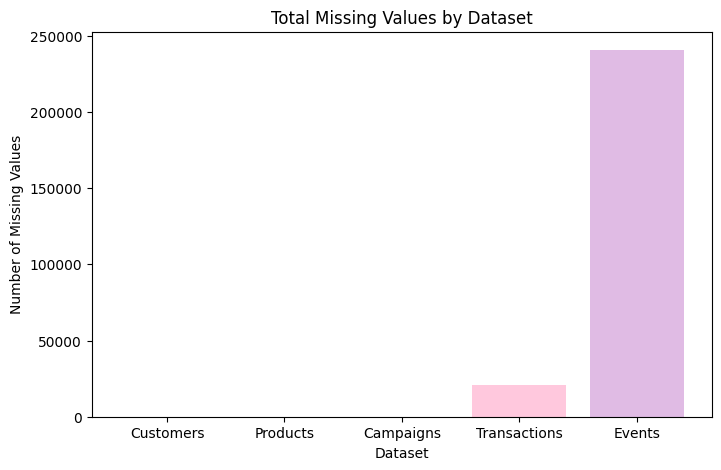

In [18]:
# Figure 1: Missing values by dataset
missing_summary = pd.DataFrame({
    'Dataset': ['Customers', 'Products', 'Campaigns', 'Transactions', 'Events'],
    'Missing Values': [
        customers.isnull().sum().sum(),
        products.isnull().sum().sum(),
        campaigns.isnull().sum().sum(),
        transactions.isnull().sum().sum(),
        events.isnull().sum().sum()
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(missing_summary['Dataset'], missing_summary['Missing Values'], color=pastel_palette)
plt.title('Total Missing Values by Dataset')
plt.xlabel('Dataset')
plt.ylabel('Number of Missing Values')
plt.show()

**Figure 1:**

The bar plot shows that missing values are mainly found in the transactions and events datasets, while the customers, products, and campaigns files are complete. The events table has the highest number of missing values because event data often includes actions that are not linked to every field, such as product or campaign information.



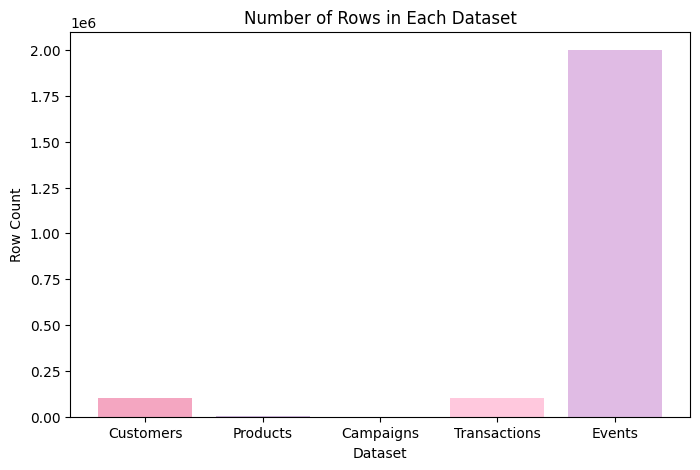

In [19]:
# Figure 2: Dataset size by rows
size_summary = pd.DataFrame({
    'Dataset': ['Customers', 'Products', 'Campaigns', 'Transactions', 'Events'],
    'Rows': [
        customers.shape[0],
        products.shape[0],
        campaigns.shape[0],
        transactions.shape[0],
        events.shape[0]
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(size_summary['Dataset'], size_summary['Rows'], color=pastel_palette)
plt.title('Number of Rows in Each Dataset')
plt.xlabel('Dataset')
plt.ylabel('Row Count')
plt.show()

**Figure 2:**

This bar plot compares the number of records in each dataset. It shows that the events dataset has the largest number of rows, followed by transactions and customers, while the campaigns table is the smallest. This means the dataset contains much more behavioral activity than reference data, which is useful for studying customer actions and purchase behavior.

## **4. Data Cleaning and Preprocessing**

The datasets were cleaned to fix missing values and prepare the columns for analysis. Date columns were converted to datetime format, and selected variables were converted to appropriate data types for analysis and modeling.

**a. Convert date columns**

In [20]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
products['launch_date'] = pd.to_datetime(products['launch_date'])
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'])
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'])
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'])
events['timestamp'] = pd.to_datetime(events['timestamp'])

**b. Check duplicates**


In [21]:
print("Customers duplicates:", customers.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())
print("Campaigns duplicates:", campaigns.duplicated().sum())
print("Transactions duplicates:", transactions.duplicated().sum())
print("Events duplicates:", events.duplicated().sum())

Customers duplicates: 0
Products duplicates: 0
Campaigns duplicates: 0
Transactions duplicates: 0
Events duplicates: 0


**c. Handle missing values**

In [22]:
# Handle missing values in transactions
transactions = transactions.dropna(subset=['product_id', 'gross_revenue'])

In [23]:
# Handle missing values in events
events = events.dropna(subset=['event_type', 'traffic_source', 'campaign_id', 'page_category', 'session_duration_sec', 'experiment_group'])
events['device_type'] = events['device_type'].fillna('Unknown')

**d. Fix data types**

In [24]:
transactions['product_id'] = transactions['product_id'].astype(int)
events['product_id'] = events['product_id'].fillna(0).astype(int)
events['campaign_id'] = events['campaign_id'].astype(int)
products['is_premium'] = products['is_premium'].astype(int)
transactions['refund_flag'] = transactions['refund_flag'].astype(int)

**e. Check the results after cleaning**

In [25]:
print("Transactions missing values:")
print(transactions.isnull().sum())

print("\nEvents missing values:")
print(events.isnull().sum())

Transactions missing values:
transaction_id      0
timestamp           0
customer_id         0
product_id          0
quantity            0
discount_applied    0
gross_revenue       0
campaign_id         0
refund_flag         0
dtype: int64

Events missing values:
event_id                0
timestamp               0
customer_id             0
session_id              0
event_type              0
product_id              0
device_type             0
traffic_source          0
campaign_id             0
page_category           0
session_duration_sec    0
experiment_group        0
dtype: int64


## **5. Merge the Files**

I merged the files to create one dataset for analysis and modeling using the common keys (id's) shared across the tables. This created a single dataset that combines customer attributes, product details, campaign characteristics, transaction records, and user event activity.

After merging, some missing values appeared in product and campaign variables because not every event record had a matching product or campaign entry. These missing values were kept because they may contain useful information.

In [26]:
merged_data = events.merge(customers, on='customer_id', how='left')
merged_data = merged_data.merge(products, on='product_id', how='left')
merged_data = merged_data.merge(campaigns, on='campaign_id', how='left')

**Helper columns**

In [27]:
print("Missing product matches:", merged_data['category'].isnull().sum())
print("Missing campaign matches:", merged_data['channel'].isnull().sum())

Missing product matches: 200371
Missing campaign matches: 1000251


In [28]:
merged_data['campaign_status'] = np.where(
    merged_data['channel'].isnull(),
    'No Campaign',
    'Campaign Linked'
)

merged_data['product_status'] = np.where(
    merged_data['category'].isnull(),
    'No Product',
    'Product Linked'
)


In [29]:
merged_data['launch_date'] = pd.to_datetime(merged_data['launch_date'])
merged_data['start_date'] = pd.to_datetime(merged_data['start_date'])
merged_data['end_date'] = pd.to_datetime(merged_data['end_date'])

**Check the merged dataset**

In [30]:
merged_data.shape

(2000000, 31)

In [31]:
merged_data.head()

,event_id,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,...,launch_date,is_premium,channel,objective,start_date,end_date,target_segment,expected_uplift,campaign_status,product_status
0,1,2021-01-14 13:35:43,43812,535101,view,1004,desktop,Email,43,PLP,...,2021-08-31,0.0,Paid Search,Cross-sell,2023-03-12,2023-04-18,Deal Seekers,0.078,Campaign Linked,Product Linked
1,2,2021-12-03 21:36:50,71340,96426,add_to_cart,986,desktop,Email,10,PDP,...,2022-04-10,0.0,Email,Cross-sell,2022-09-01,2022-10-22,Churn Risk,0.034,Campaign Linked,Product Linked
2,3,2021-12-27 08:25:15,59540,220126,purchase,1630,mobile,Organic,0,PDP,...,2022-11-02,0.0,NaN,NaN,NaT,NaT,NaN,NaN,No Campaign,Product Linked
3,4,2022-01-22 15:06:54,3601,484555,add_to_cart,1532,desktop,Paid Search,30,Checkout,...,2022-08-17,0.0,Social,Acquisition,2023-11-04,2024-01-06,Deal Seekers,0.052,Campaign Linked,Product Linked
4,5,2021-05-10 12:03:09,92735,60646,bounce,0,desktop,Email,26,PLP,...,NaT,NaN,Email,Reactivation,2023-08-13,2023-11-01,Deal Seekers,0.037,Campaign Linked,No Product


In [32]:
merged_data.columns

Index(['event_id', 'timestamp', 'customer_id', 'session_id', 'event_type',
       'product_id', 'device_type', 'traffic_source', 'campaign_id',
       'page_category', 'session_duration_sec', 'experiment_group',
       'signup_date', 'country', 'age', 'gender', 'loyalty_tier',
       'acquisition_channel', 'category', 'brand', 'base_price', 'launch_date',
       'is_premium', 'channel', 'objective', 'start_date', 'end_date',
       'target_segment', 'expected_uplift', 'campaign_status',
       'product_status'],
      dtype='object')

In [33]:
# Check missing values after merge
merged_data.isnull().sum()

,0
event_id,0
timestamp,0
customer_id,0
session_id,0
event_type,0
product_id,0
device_type,0
traffic_source,0
campaign_id,0
page_category,0


## **6. Exploratory Data Analysis (EDA)**

 This step helps summarize the data before modeling and highlights how customer interactions, device usage, loyalty groups, and traffic sources are distributed.

 The results showed that product views were the most common event while purchase events were less frequent. Mobile devices was the largest share of activity, and most customers belonged to the Bronze loyalty tier. Organic traffic was the largest traffic source, and the age distribution showed that most customers were concentrated in the adult age range.

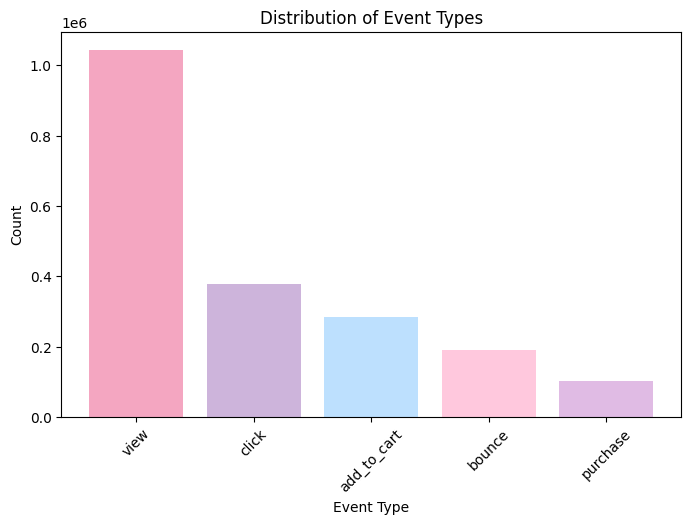

In [34]:
# Event type distribution
event_counts = merged_data['event_type'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(event_counts.index, event_counts.values, color=pastel_palette)
plt.title('Distribution of Event Types')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Figure 3:** Distribution of Event Types

The event type chart shows that view is the most common action by a large margin, followed by click and add_to_cart. Purchase has the lowest count among the main customer actions whivh suggests that many users interact with products at the early stages of the shopping process, but only a smaller share completes a purchase. The pattern is consistent with a typical customer funnel, where the number of users decreases from viewing to buying.

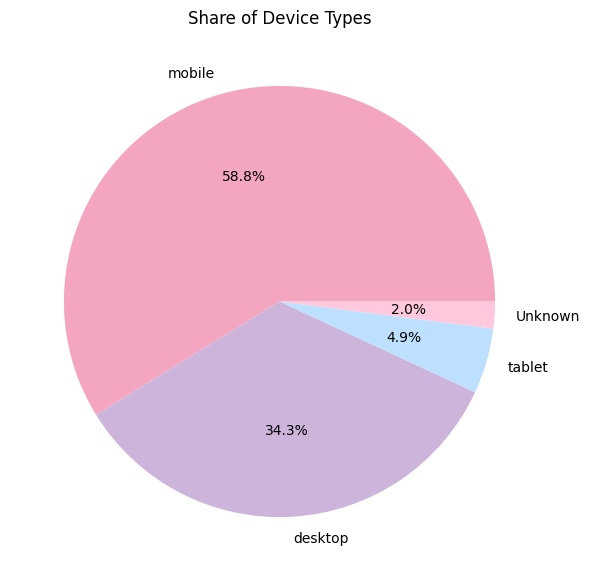

In [35]:
# Device type distribution
device_counts = merged_data['device_type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%', colors=pastel_palette)
plt.title('Share of Device Types')
plt.show()

**Figure 4:** Distribution of Device Types

The device type pie chart shows that mobile is the most frequently used device, followed by desktop, while tablet and Unknown appear much less often. This suggests that most customer activity happens on mobile devices, which means mobile behavior may be especially important when analyzing engagement and purchase patterns.


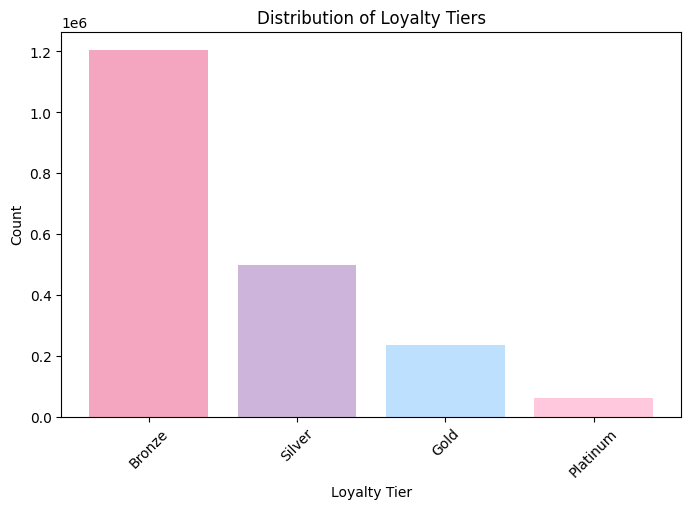

In [36]:
#Loyalty tier distribution
loyalty_counts = merged_data['loyalty_tier'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(loyalty_counts.index, loyalty_counts.values, color=pastel_palette)
plt.title('Distribution of Loyalty Tiers')
plt.xlabel('Loyalty Tier')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


**Figure 5:** Distribution of Loyalty Tiers

The loyalty tier chart shows that Bronze customers make up the largest group, followed by Silver, Gold, and Platinum. This means the customer base is concentrated in the lower loyalty levels, while the highest tier contains the fewest users. This may be useful later when checking whether purchase behavior differs across loyalty groups.



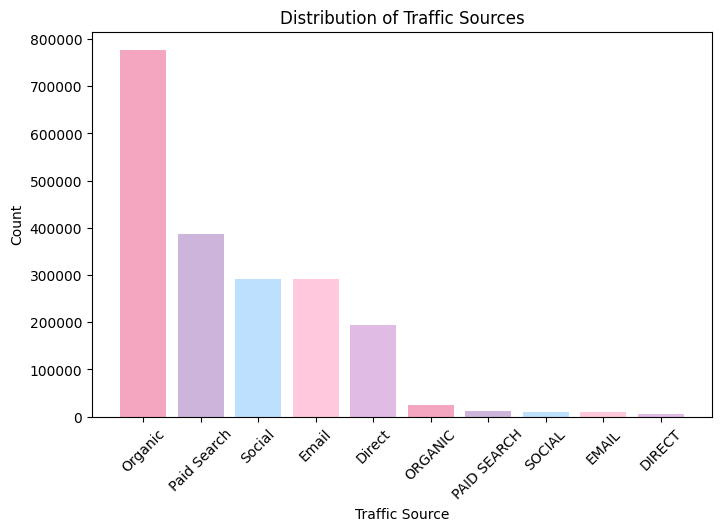

In [37]:
# Traffic source distribution
traffic_counts = merged_data['traffic_source'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(traffic_counts.index, traffic_counts.values, color=pastel_palette)
plt.title('Distribution of Traffic Sources')
plt.xlabel('Traffic Source')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Figure 6:** Distribution of Traffic Sources

The traffic source chart shows that Organic is the largest traffic source, followed by Paid Search, while Social, Email, and Direct appear at lower levels. The chart also shows repeated labels in different letter formats, such as Organic and ORGANIC, which suggests that the traffic source column contains inconsistent text formatting. This indicates that the variable should be standardized later so the categories are treated correctly in the analysis.


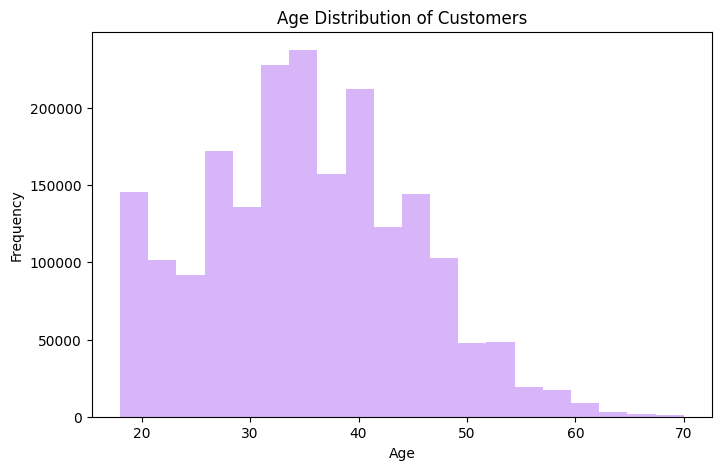

In [38]:
# Age distribution
plt.figure(figsize=(8,5))
plt.hist(merged_data['age'], bins=20, color='#d8b4f8')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Figure 7:** Age Distribution of Customers

The age distribution shows that most customers are concentrated in the adult age range, especially around the late 20s to early 40s. The number of customers becomes lower at the older ages. This suggests that the main customer base is made up of working-age adults, which may influence product interest, engagement patterns, and purchase likelihood.

## **7. Feature Engineering**

The created variables were derived from existing customer, event, and campaign information to better represent user behavior and business context.

The new variables focus on time-based information, customer grouping, and event-level indicators. Additional helper columns were created to indicate whether an event was linked to a product or a campaign.

**New variables:**
- event hour
- event day
- signup year
- age group
- purchase flag (target variable)


**a. Create time-based features**

In [39]:
merged_data['event_hour'] = merged_data['timestamp'].dt.hour
merged_data['event_day'] = merged_data['timestamp'].dt.day_name()
merged_data['signup_year'] = merged_data['signup_date'].dt.year

**b. create age group**

In [40]:
merged_data['age_group'] = pd.cut(
    merged_data['age'],
    bins=[18, 25, 35, 45, 55, 70],
    labels=['18-25', '26-35', '36-45', '46-55', '56-70'],
    include_lowest=True
)

**c. Create flags**

In [41]:
# Create purchase flag from event type
merged_data['purchase_flag'] = (merged_data['event_type'] == 'purchase').astype(int)

In [42]:
# Create add-to-cart flag
merged_data['cart_flag'] = (merged_data['event_type'] == 'add_to_cart').astype(int)

In [43]:
# Create click flag
merged_data['click_flag'] = (merged_data['event_type'] == 'click').astype(int)

**d. Standardize text columns**

Important because the traffic source chart showed repeated values with different letter formats


In [44]:
merged_data['traffic_source'] = merged_data['traffic_source'].str.lower()
merged_data['device_type'] = merged_data['device_type'].str.lower()
merged_data['event_type'] = merged_data['event_type'].str.lower()
merged_data['loyalty_tier'] = merged_data['loyalty_tier'].str.lower()

**e. Check the new columns**

In [45]:
print(merged_data[['event_hour', 'event_day', 'signup_year', 'age_group', 'purchase_flag', 'cart_flag', 'click_flag']].head())

   event_hour event_day  signup_year age_group  purchase_flag  cart_flag  \
0          13  Thursday         2022     56-70              0          0   
1          21    Friday         2021     18-25              0          1   
2           8    Monday         2021     36-45              1          0   
3          15  Saturday         2022     26-35              0          1   
4          12    Monday         2022     36-45              0          0   

   click_flag  
0           0  
1           0  
2           0  
3           0  
4           0  


## **8. Define Target Variable**

The target variable for this project is whether an event resulted in a purchase. Represented by purchase_flag, where a value of 1 = purchase event and a value of 0 = non-purchase event (binary classification problem).

The target distribution showed strong class imbalance (94.84% of the records are non-purchase events). Because of this, model evaluation should not rely only on accuracy, but on precision, recall, and F1-score too.

In [46]:
merged_data['purchase_flag'].value_counts()

,count
purchase_flag,
0,1896873
1,103127


In [47]:
merged_data['purchase_flag'].value_counts(normalize=True)

,proportion
purchase_flag,
0,0.948437
1,0.051563


## **9. Prepare Features and Split the Data**
Before training the models, the target variable was separated from the input features. Unique identifiers, timestamps, and variables that  revealed the purchase outcome were removed from the predictor set.

The dataset was then split into training and testing sets using stratified sampling (because of the large size of the full dataset), so that the class distribution remained consistent in both sets.

In [48]:
sample_data = merged_data.sample(n=200000, random_state=42)

In [49]:
X = sample_data.drop(columns=[
    'purchase_flag',
    'event_id',
    'customer_id',
    'session_id',
    'product_id',
    'campaign_id',
    'timestamp',
    'signup_date',
    'launch_date',
    'start_date',
    'end_date',
    'event_type',
    'cart_flag',
    'click_flag'
])

y = sample_data['purchase_flag']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # To keep the same class ratio in both sets because the target is imbalanced
)

In [51]:
print(X_train.shape)
print(X_test.shape)

(160000, 24)
(40000, 24)


In [52]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

purchase_flag
0    0.947994
1    0.052006
Name: proportion, dtype: float64
purchase_flag
0    0.948
1    0.052
Name: proportion, dtype: float64


## **10. Build Predictive Models**

**Three predictive approaches were evaluated:**

**a.** Random Forest as an ensemble learning method
- To test whether a tree-based model could better capture complex patterns in the data.

**b.** Logistic Regression as a baseline classification model
- Used as a simpler classification model

**c.** AutoML as an automated model search approach
- To automatically search for a strong alternative model within a limited time budget

#### **Preprocessing:**
**a. Define categorical and numerical columns**

In [53]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

**b. Create the preprocessing steps**

In [54]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

**c. Create the full preprocessor**


In [55]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

#### **Random forest**

In [56]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['session_duration_sec',
                                                   'age', 'base_price',
                                                   'is_premium',
                                                   'expected_uplift']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['device_type',
                                                   'traffic_source',
                                                   'page_category',
                                                   'experiment_group',
                                                   'country', 'gender',
                                                   'loyalty_tier',
                                                   'acquisition_channel',
                                                   'category', 'brand',
                                                   'channel', 'objective',
                                                   'target_segment',
                                                   'campaign_status',
                                                   'product_status',
                                                   'event_day',
                                                   'age_group'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=10, n_estimators=50,
                                        n_jobs=-1, random_state=42))])

#### **Logistic regression**

In [57]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['session_duration_sec',
                                                   'age', 'base_price',
                                                   'is_premium',
                                                   'expected_uplift']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['device_type',
                                                   'traffic_source',
                                                   'page_category',
                                                   'experiment_group',
                                                   'country', 'gender',
                                                   'loyalty_tier',
                                                   'acquisition_channel',
                                                   'category', 'brand',
                                                   'channel', 'objective',
                                                   'target_segment',
                                                   'campaign_status',
                                                   'product_status',
                                                   'event_day',
                                                   'age_group'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## **11. Evaluate Models**

Because the target variable is highly imbalanced, the evaluation focused on precision, recall, F1-score, and confusion matrices and accuracy.

The Random Forest model achieved high recall for the purchase class but produced many false positives. The AutoML model achieved high overall accuracy but performed poorly on the purchase class because it was heavily biased toward the majority non-purchase class. The initial Logistic Regression model also showed weak precision, so threshold tuning was applied to improve the balance between detecting purchases and reducing false positives.

After comparison, the tuned Logistic Regression model was selected as the final model because it provided the most practical balance between identifying purchase events and controlling false positives.

#### **Random forest evaluation**

In [58]:
rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

rf_cm = confusion_matrix(y_test, rf_preds)
print(rf_cm)

Random Forest Accuracy: 0.54775
              precision    recall  f1-score   support

           0       0.98      0.54      0.69     37920
           1       0.08      0.77      0.15      2080

    accuracy                           0.55     40000
   macro avg       0.53      0.65      0.42     40000
weighted avg       0.93      0.55      0.66     40000

[[20306 17614]
 [  476  1604]]


**Random Forest results:**

- Accuracy: 0.55
- Precision: 0.08
- Recall: 0.77
- F1: 0.15

Confusion matrix:

- 20306 true negatives
- 17614 false positives
- 476 false negatives
- 1604 true positives



#### **Logistic regression evaluation**

In [59]:
lr_preds = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

lr_cm = confusion_matrix(y_test, lr_preds)
print(lr_cm)

Logistic Regression Accuracy: 0.570525
              precision    recall  f1-score   support

           0       0.98      0.56      0.71     37920
           1       0.08      0.74      0.15      2080

    accuracy                           0.57     40000
   macro avg       0.53      0.65      0.43     40000
weighted avg       0.93      0.57      0.68     40000

[[21284 16636]
 [  543  1537]]


#### **Threshold tuning**

In [60]:
lr_probs = lr_model.predict_proba(X_test)[:, 1]

preds_060 = (lr_probs >= 0.60).astype(int)
preds_070 = (lr_probs >= 0.70).astype(int)
preds_080 = (lr_probs >= 0.80).astype(int)

#### **Final threshold result**

In [61]:
print(classification_report(y_test, preds_060))
print(confusion_matrix(y_test, preds_060))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     37920
           1       0.09      0.52      0.16      2080

    accuracy                           0.72     40000
   macro avg       0.53      0.62      0.49     40000
weighted avg       0.92      0.72      0.79     40000

[[27521 10399]
 [  999  1081]]


**Logistic Regression at 0.60:**

- Accuracy: 0.72
- Precision: 0.09
- Recall: 0.52
- F1: 0.16

Confusion matrix:

- 27521 true negatives
- 10399 false positives
- 999 false negatives
- 1081 true positives



#### **Confusion matrix plot**

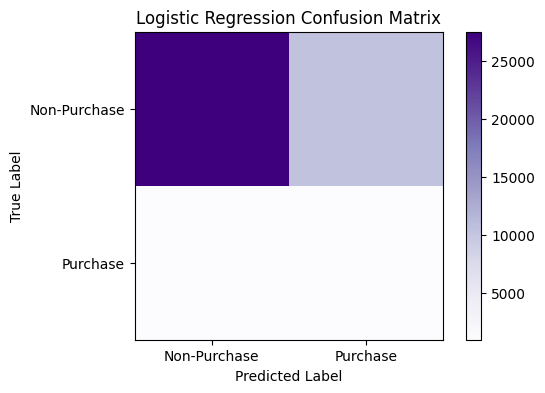

In [62]:
plt.figure(figsize=(6,4))
plt.imshow(confusion_matrix(y_test, preds_060), interpolation='nearest', cmap='Purples')
plt.title('Logistic Regression Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['Non-Purchase', 'Purchase'])
plt.yticks([0, 1], ['Non-Purchase', 'Purchase'])
plt.show()

**Figure 8:**

This confusion matrix shows the performance of the tuned Logistic Regression model after changing the decision threshold. The top-left value 27521, represents non-purchase events that were correctly classified as non-purchase. The top-right value 10399, represents non-purchase events that were incorrectly classified as purchase. The bottom-left value 999, shows purchase events that the model failed to identify, while the bottom-right value 1081, represents purchase events that were correctly predicted.

## **12. AutoML Model**

The AutoML model selected an XGBoost classifier as the best configuration. It achieved a high overall accuracy of 91.96%, but its performance on the purchase class was weak. The model identified only 81 true purchase events and produced a recall of 4% for the purchase class. This shows that the AutoML model was really biased toward predicting the majority non-purchase class.




**a. Run AutoML**

In [63]:
automl = AutoML()

automl_settings = {
    "time_budget": 300,
    "metric": "f1",
    "task": "classification",
    "log_file_name": "flaml_automl.log",
    "seed": 42
}

automl.fit(
    X_train=X_train,
    y_train=y_train,
    **automl_settings
)

[flaml.automl.logger: 03-26 22:46:01] {2375} INFO - task = classification
[flaml.automl.logger: 03-26 22:46:01] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 03-26 22:46:01] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 03-26 22:46:01] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 03-26 22:46:01] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 03-26 22:46:01] {3046} INFO - Estimated sufficient time budget=16316s. Estimated necessary time budget=378s.
[flaml.automl.logger: 03-26 22:46:01] {3097} INFO -  at 3.1s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 03-26 22:46:01] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 03-26 22:46:01] {3097} INFO -  at 3.2s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.aut

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 03-26 22:46:01] {3097} INFO -  at 3.4s,	estimator sgd's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 03-26 22:46:01] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 03-26 22:46:02] {3097} INFO -  at 3.5s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 03-26 22:46:02] {2911} INFO - iteration 5, current learner lgbm
[flaml.automl.logger: 03-26 22:46:02] {3097} INFO -  at 3.6s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 03-26 22:46:02] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 03-26 22:46:02] {3097} INFO -  at 3.7s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 03-26 22:46:02] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 03-26 22:46:02] {3097} INFO -  at 3.7s,	estimator l

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 03-26 22:49:37] {3097} INFO -  at 218.7s,	estimator lrl1's best error=1.0000e+00,	best estimator xgb_limitdepth's best error=9.1827e-01
[flaml.automl.logger: 03-26 22:49:37] {2911} INFO - iteration 218, current learner lrl1
[flaml.automl.logger: 03-26 22:49:38] {3097} INFO -  at 219.5s,	estimator lrl1's best error=1.0000e+00,	best estimator xgb_limitdepth's best error=9.1827e-01
[flaml.automl.logger: 03-26 22:49:38] {2911} INFO - iteration 219, current learner lrl1
[flaml.automl.logger: 03-26 22:49:38] {3097} INFO -  at 220.3s,	estimator lrl1's best error=1.0000e+00,	best estimator xgb_limitdepth's best error=9.1827e-01
[flaml.automl.logger: 03-26 22:49:38] {2911} INFO - iteration 220, current learner xgboost
[flaml.automl.logger: 03-26 22:49:39] {3097} INFO -  at 220.8s,	estimator xgboost's best error=1.0000e+00,	best estimator xgb_limitdepth's best error=9.1827e-01
[flaml.automl.logger: 03-26 22:49:39] {2911} INFO - iteration 221, current learner xgboost
[flaml.

**b. Check the best model**

In [64]:
print("Best model:", automl.model.estimator)
print("Best config:", automl.best_config)

Best model: XGBClassifier(base_score=None, booster=None, callbacks=[],
              colsample_bylevel=np.float64(0.889463643453186),
              colsample_bynode=None, colsample_bytree=1.0, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1.0, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=np.float64(0.3517885812929992), missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=149,
              n_jobs=-1, num_parallel_tree=None, random_state=None, ...)
Best config: {'n_estimators': 149, 'max_depth': 8, 'min_child_weight': np.float64(0.3517885812929992), 'learning_rate': 1.0, 'subsample': np.float64(0.7429542738784519), 'cols

**c. Evaluate AutoML**

In [65]:
auto_preds = automl.predict(X_test)

print("AutoML Accuracy:", accuracy_score(y_test, auto_preds))
print(classification_report(y_test, auto_preds))

auto_cm = confusion_matrix(y_test, auto_preds)
print(auto_cm)

AutoML Accuracy: 0.900425
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     37920
           1       0.08      0.08      0.08      2080

    accuracy                           0.90     40000
   macro avg       0.51      0.51      0.51     40000
weighted avg       0.90      0.90      0.90     40000

[[35848  2072]
 [ 1911   169]]


**AutoML result:**

- Accuracy: 0.92
- Precision: 0.06
- Recall: 0.04
- F1: 0.05

Confusion matrix:

- 36701 true negatives
- 1219 false positives
- 1999 false negatives
- 81 true positives



**d. Confusion matrix plot**

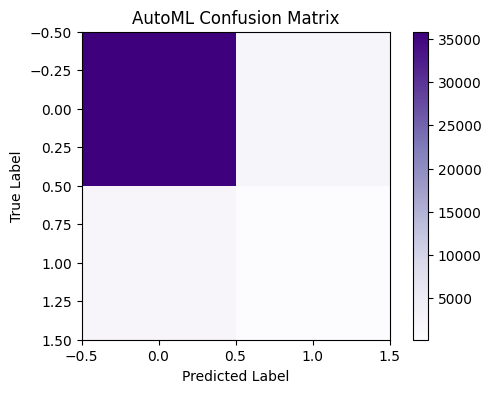

In [66]:
plt.figure(figsize=(6,4))
plt.imshow(auto_cm, interpolation='nearest', cmap='Purples')
plt.title('AutoML Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Figure 9:** AutoML Confusion Matrix

The confusion matrix shows that the AutoML model correctly classified 36848 non-purchase events and only 93 purchase events. It also incorrectly predicted 1072 non-purchase events as purchases and failed to identify 1987 actual purchase events. This means the model performed well on the majority non-purchase class but struggled to detect purchase events. As a result, the figure shows that the AutoML model was too focused on the majority class and was not effective enough for the main goal of purchase prediction.

## **13.SHAP Explainability**

SHAP is used to explain the final prediction model and identify which variables had the strongest influence on purchase prediction. Because the dataset is large, a smaller sample was used for explainability analysis.

The SHAP results showed that campaign status, traffic source, loyalty tier, experiment group, expected uplift, and base price were among the most important variables influencing the model's predictions. Which helps understand how the model makes decisions and improves the transparency of the results.


**a. Transform a small sample**


In [67]:
X_shap_sample = X_test.sample(n=1000, random_state=42)

X_shap_processed = lr_model.named_steps['preprocessor'].transform(X_shap_sample)
lr_classifier = lr_model.named_steps['classifier']

**b. Create feature names**

In [68]:
cat_names = lr_model.named_steps['preprocessor'].named_transformers_['cat'] \
    .named_steps['onehot'].get_feature_names_out(categorical_cols)

feature_names = numerical_cols + list(cat_names)

**c. Create SHAP explainer**


In [69]:
explainer = shap.Explainer(lr_classifier, X_shap_processed, feature_names=feature_names)
shap_values = explainer(X_shap_processed)

**d. Summary plot**

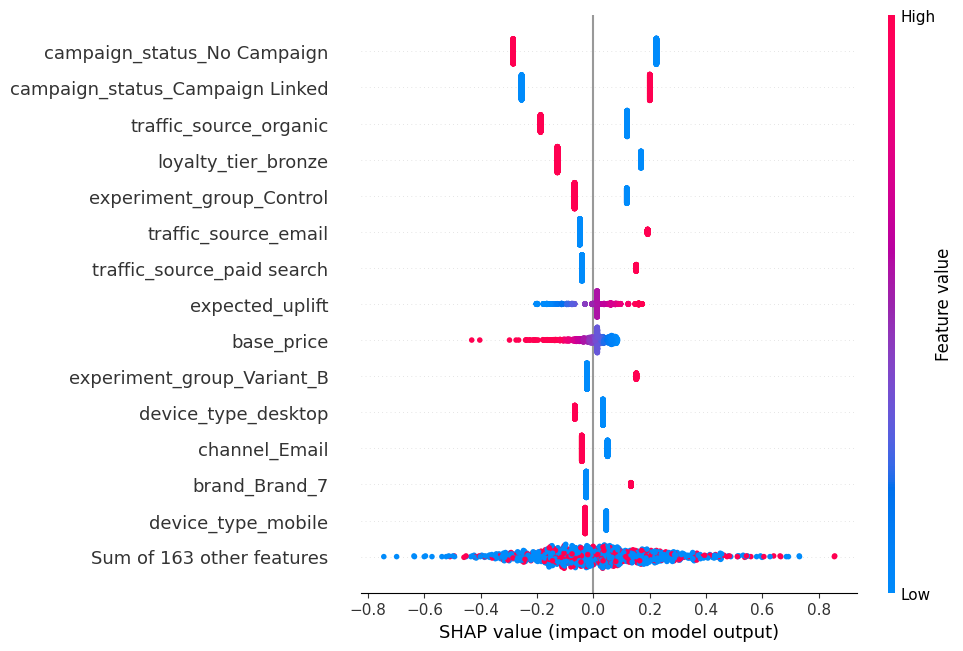

In [70]:
shap.plots.beeswarm(shap_values, max_display=15)

**Figure 10:** The SHAP summary plot shows how the most important features affect the model output. The results suggest that campaign status, traffic source, loyalty tier, experiment group, expected uplift, and base price have the strongest influence on purchase prediction. Features on the right increase the model output, while features on the left decrease it.


**e. bar plot**


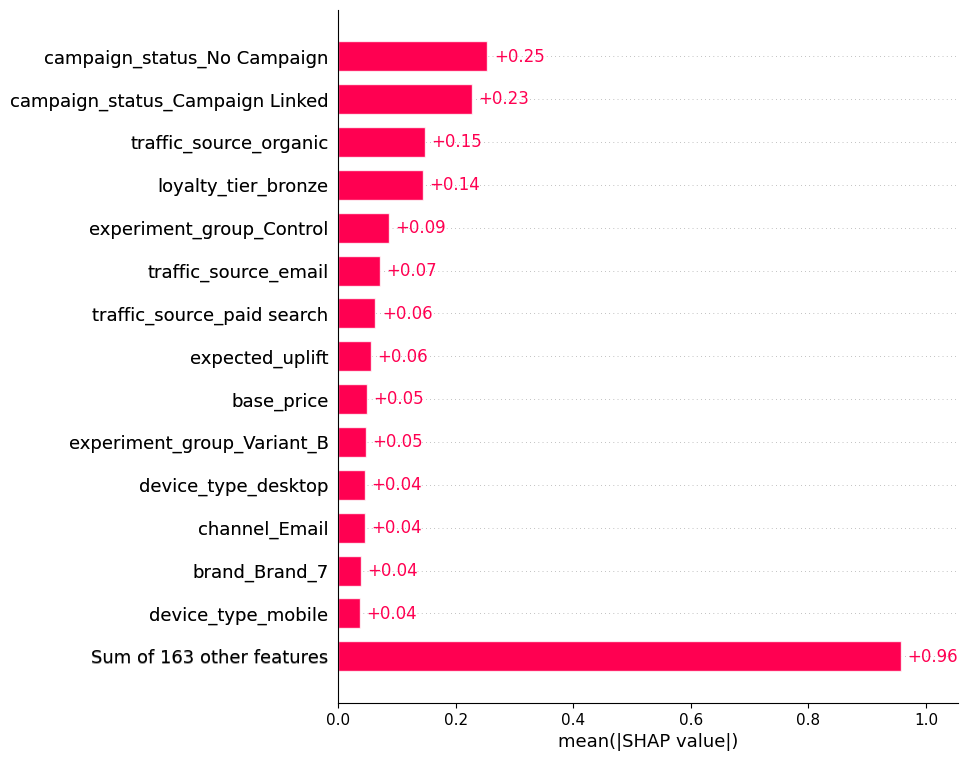

In [71]:
shap.plots.bar(shap_values, max_display=15)


**Figure 11:** The SHAP bar plot ranks features by overall importance. The most influential variables are campaign status, organic traffic source, bronze loyalty tier, experiment group, expected uplift, and base price. This shows that the model depends mainly on campaign-related, traffic-related, and customer-related factors when predicting purchase behavior.

## **14. Bias Analysis**

Bias analysis was conducted to examine whether the final model performed differently across selected customer groups. The analysis focused on gender, age group, and country by comparing actual and predicted outcomes and group-level accuracy.

The results showed that actual purchase rates were  similar across gender and age groups, while predicted purchase rates were higher for all groups. Accuracy was relatively close across gender and age groups, which suggests no major performance gap between those groups. Some variation was shown across countries, so its behavior is not fully uniform across all segments.

**a. Create final predictions using the chosen threshold**

In [72]:
final_preds = preds_060

**b. Create a results table**

In [73]:
results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = final_preds

**c. Bias check by gender**


In [74]:
gender_bias = results.groupby('gender')[['actual', 'predicted']].mean()
print(gender_bias)

          actual  predicted
gender                     
Female  0.052747   0.277028
Male    0.051468   0.295267
Other   0.049415   0.306892


**d. Bias check by age group**

In [75]:
age_bias = results.groupby('age_group', observed=False)[['actual', 'predicted']].mean()
print(age_bias)

             actual  predicted
age_group                     
18-25      0.053333   0.287473
26-35      0.051673   0.286233
36-45      0.052040   0.290582
46-55      0.052242   0.275821
56-70      0.044725   0.303899


**e. Bias check by country**


In [76]:
country_bias = results.groupby('country')[['actual', 'predicted']].mean()
print(country_bias)

           actual  predicted
country                     
AU       0.053775   0.268877
BR       0.055556   0.316594
CA       0.052422   0.274534
DE       0.051142   0.338372
IN       0.050145   0.265804
UK       0.050145   0.262355
US       0.052281   0.293316


**f. Accuracy by group**

In [77]:
# Gender accuracy
gender_accuracy = (results['actual'] == results['predicted']).groupby(results['gender']).mean()
print(gender_accuracy)

gender
Female    0.724123
Male      0.707007
Other     0.703511
dtype: float64


In [78]:
# Age group accuracy
age_accuracy = (results['actual'] == results['predicted']).groupby(results['age_group'], observed=False).mean()
print(age_accuracy)

age_group
18-25    0.709890
26-35    0.716815
36-45    0.712374
46-55    0.725981
56-70    0.706422
dtype: float64


## **15. Save Model and Scoring Code**



**a. Packaging**

In [79]:
joblib.dump(lr_model, 'final_logistic_model.pkl')
joblib.dump(0.60, 'final_threshold.pkl')

['final_threshold.pkl']

**b. Scoring script**

In [80]:
saved_model = joblib.load('final_logistic_model.pkl')
saved_threshold = joblib.load('final_threshold.pkl')

def score_new_data(new_data):
    probabilities = saved_model.predict_proba(new_data)[:, 1]
    predictions = (probabilities >= saved_threshold).astype(int)

    results = new_data.copy()
    results['purchase_probability'] = probabilities
    results['predicted_purchase'] = predictions

    return results

**c. Short example call**

In [81]:
example_results = score_new_data(X_test.head(5))
print(example_results)

        device_type traffic_source page_category  session_duration_sec  \
1362628     desktop        organic          Home                 177.5   
1678980      mobile    paid search           PLP                 429.3   
370603       mobile         direct           PLP                 258.0   
1221654      mobile        organic           PLP                  34.7   
971663       mobile         direct          Home                 555.9   

        experiment_group country  age  gender loyalty_tier  \
1362628          Control      US   44    Male       bronze   
1678980          Control      CA   28    Male       bronze   
370603         Variant_B      US   20  Female       bronze   
1221654          Control      US   31    Male       bronze   
971663         Variant_B      IN   42    Male       silver   

        acquisition_channel  ... target_segment expected_uplift  \
1362628         Paid Search  ...            NaN             NaN   
1678980             Organic  ...     Churn Risk 

## **16. Export Data for Dashboard**



**a. Creating the file**

In [82]:
dashboard_data = merged_data.copy()
dashboard_data.to_csv('dashboard_data.csv', index=False)

**b. Downloading the file**

In [83]:
dashboard_data = merged_data.copy()
dashboard_data.to_csv('dashboard_data.csv', index=False)

### **Conclusion**
This project used a multi-file marketing and e-commerce dataset to analyze customer behavior and predict purchase events. The data was prepared through cleaning, merging, feature engineering, and exploratory analysis to identify key patterns in customer activity.

Random Forest, Logistic Regression, and AutoML were tested as predictive approaches. After correcting data leakage and comparing the models, the tuned Logistic Regression model was selected as the final model because it provided the most practical balance between detecting purchase events and controlling false positives. Although the AutoML model achieved higher overall accuracy, it performed poorly on the minority purchase class and was therefore not chosen as the final model.

SHAP analysis showed that campaign status, traffic source, loyalty tier, experiment group, expected uplift, and base price were among the most important factors influencing the model's predictions. Bias analysis showed fairly similar performance across gender and age groups, with some variation across countries. Overall, the project shows how marketing and behavioral data can be combined to support purchase prediction and business decision-making.